Titanic Survival Analysis

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib as mat

In [4]:
import seaborn as sns

Displaying the dataset:
This dataset displays the information of the passengers.

In [5]:
df =pd.read_csv("C:/Users/HP/Downloads/tested.csv")

In [6]:
pd.set_option('display.max_columns', 418)
pd.set_option('display.max_rows', 12)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Cleaning the dataset


In [9]:
df = df.drop_duplicates()

In [10]:
df = df.drop(columns=['SibSp','Parch'])
df.head(20)
df


,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,359309,8.0500,NaN,S


In [11]:
df["Ticket"].apply(lambda x: str(x))
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,A/4 48871,24.1500,NaN,S


In [12]:
df["Ticket"] = df["Ticket"].astype(str).str.replace('[^0-9]', '', regex=True)


In [13]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,53236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,359309,8.0500,NaN,S


Handling missing values


In [14]:
df['Cabin']= df['Cabin'].str[0]
df['Cabin'] =df['Cabin'].fillna('unknown')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,330911,7.8292,unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,363272,7.0000,unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,240276,9.6875,unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,315154,8.6625,unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,3101298,12.2875,unknown,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,53236,8.0500,unknown,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,17758,108.9000,C,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,3101262,7.2500,unknown,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,359309,8.0500,unknown,S


In [15]:
df['Age'] =df['Age'].fillna('unknown')
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,330911,7.8292,unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,363272,7.0000,unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,240276,9.6875,unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,315154,8.6625,unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,3101298,12.2875,unknown,S
...,...,...,...,...,...,...,...,...,...,...
10,902,0,3,"Ilieff, Mr. Ylio",male,unknown,349220,7.8958,unknown,S
11,903,0,1,"Jones, Mr. Charles Cresson",male,46.0,694,26.0000,unknown,S
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,21228,82.2667,B,S
13,905,0,2,"Howard, Mr. Benjamin",male,63.0,24065,26.0000,unknown,S


In [16]:
df[['Last_Name','First_Name']]= df['Name'].str.split(pat=',',n=1,expand=True)
df.drop(['Name'],axis=1,inplace=True)



In [17]:
df

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Last_Name,First_Name
0,892,0,3,male,34.5,330911,7.8292,unknown,Q,Kelly,Mr. James
1,893,1,3,female,47.0,363272,7.0000,unknown,S,Wilkes,Mrs. James (Ellen Needs)
2,894,0,2,male,62.0,240276,9.6875,unknown,Q,Myles,Mr. Thomas Francis
3,895,0,3,male,27.0,315154,8.6625,unknown,S,Wirz,Mr. Albert
4,896,1,3,female,22.0,3101298,12.2875,unknown,S,Hirvonen,Mrs. Alexander (Helga E Lindqvist)
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,male,unknown,53236,8.0500,unknown,S,Spector,Mr. Woolf
414,1306,1,1,female,39.0,17758,108.9000,C,C,Oliva y Ocana,Dona. Fermina
415,1307,0,3,male,38.5,3101262,7.2500,unknown,S,Saether,Mr. Simon Sivertsen
416,1308,0,3,male,unknown,359309,8.0500,unknown,S,Ware,Mr. Frederick


In [18]:
df.groupby('Sex')['Survived'].mean()


Sex
female    1.0
male      0.0
Name: Survived, dtype: float64

Survival probability is higher for females


In [19]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.467290
2    0.322581
3    0.330275
Name: Survived, dtype: float64

During rescue the first class passengers were given more priority
This indicates socioeconomic status were major determinants of survival

<Axes: title={'center': 'Pclass'}, xlabel='Survived'>

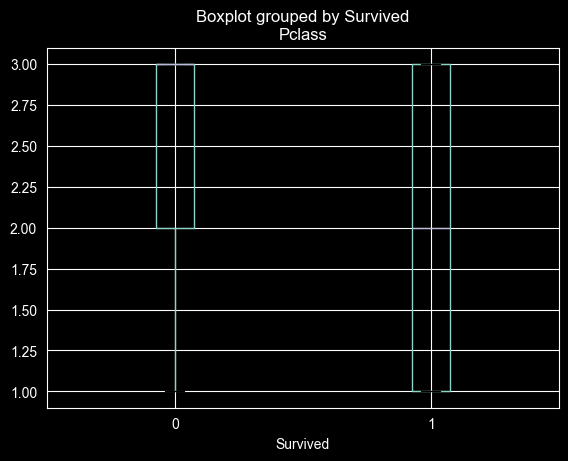

In [25]:
df.boxplot(column='Pclass',by='Survived')

    The boxplot shows that survivors are concentrated in higher passenger classes,whereas non-survivors belong to third class.
    This indicates socioeconomic status significantly influence survival outcome

<Axes: xlabel='Sex', ylabel='Survived'>

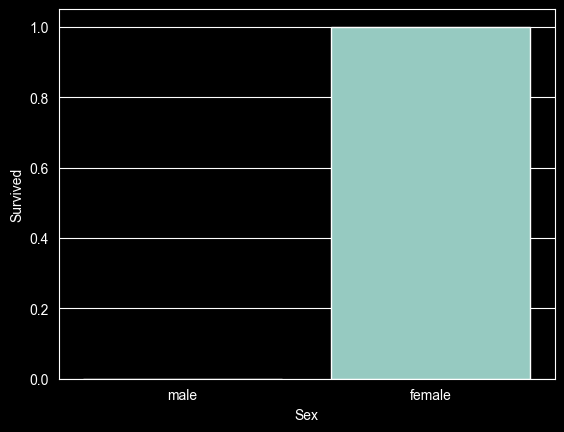

In [26]:
sns.barplot(x='Sex',y='Survived',data=df)

This bar plot shows that females have higher chances of surviving than males